# 📊 Pipeline Performance — Visualization
Visualises benchmark results from `performance_before.csv` and `performance_after.csv`.

| Chart | Title |
|-------|-------|
| 1 | Processing Time — Before vs After |
| 2 | Processing Time — All Methods |
| 3 | Memory Usage |
| 4 | Throughput |
| 5 | Speedup vs Baseline |
| 6 | Combined — Time, CPU, Memory, Throughput |

## Step 1 — Import

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import os

plt.rcParams.update({
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'figure.dpi':        120,
    'font.size':         10,
})

print('✅ Ready.')

✅ Ready.


## Step 2 — Load & Prepare Data

In [2]:
df_before = pd.read_csv('performance_before.csv')
df_raw    = pd.read_csv('performance_after.csv')

print('performance_before.csv:')
display(df_before)

print('\nperformance_after.csv (raw):')
display(df_raw)

df_avg = (
    df_raw
    .dropna(subset=['avg_time_sec'])
    [['method', 'avg_time_sec', 'avg_cpu_%',
      'avg_memory_mb', 'avg_throughput', 'speedup_vs_baseline']]
    .rename(columns={
        'avg_time_sec':   'time_sec',
        'avg_cpu_%':      'cpu_percent',
        'avg_memory_mb':  'memory_mb',
        'avg_throughput': 'throughput_records_per_sec',
    })
    .reset_index(drop=True)
)

print('\nCleaned df_avg (1 row per method):')
display(df_avg)

COLORS        = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
methods       = df_avg['method'].tolist()
labels        = [m.replace('_', ' ').title() for m in methods]
colors        = COLORS[:len(methods)]
baseline_time = df_before['time_sec'].values[0]

print(f'\n✅ {len(df_avg)} methods ready: {methods}')
print(f'   Baseline time: {baseline_time:.4f}s')

performance_before.csv:


,method,time_sec,time_min,time_max,cpu_percent,memory_mb,throughput_records_per_sec,rows_processed
0,pandas_baseline,6.6705,4.1934,11.1974,78.7,251.17,18220.0,100442



performance_after.csv (raw):


,method,run,time_sec,cpu_%,memory_mb,throughput,avg_time_sec,avg_cpu_%,avg_memory_mb,avg_throughput,speedup_vs_baseline
0,pandas_baseline,1,11.1974,47.0,251.16,8970,NaN,NaN,NaN,NaN,NaN
1,pandas_baseline,2,4.1934,91.7,251.16,23952,6.6705,78.70,251.17,18220.0,1.00
2,pandas_baseline,3,4.6205,97.4,251.17,21738,NaN,NaN,NaN,NaN,NaN
3,pandas_optimized,1,3.7298,100.0,213.61,26930,NaN,NaN,NaN,NaN,NaN
4,pandas_optimized,2,5.0461,98.4,213.61,19905,4.2360,99.47,213.61,24126.0,1.57
5,pandas_optimized,3,3.9322,100.0,213.61,25544,NaN,NaN,NaN,NaN,NaN
6,polars,1,0.9320,113.7,0.09,58641,NaN,NaN,NaN,NaN,NaN
7,polars,2,0.8334,124.7,0.04,65582,0.8368,123.70,0.06,65861.0,7.97
8,polars,3,0.7450,132.7,0.04,73360,NaN,NaN,NaN,NaN,NaN
9,duckdb,1,1.3341,107.2,0.15,40965,NaN,NaN,NaN,NaN,NaN



Cleaned df_avg (1 row per method):


,method,time_sec,cpu_percent,memory_mb,throughput_records_per_sec,speedup_vs_baseline
0,pandas_baseline,6.6705,78.70,251.17,18220.0,1.00
1,pandas_optimized,4.2360,99.47,213.61,24126.0,1.57
2,polars,0.8368,123.70,0.06,65861.0,7.97
3,duckdb,1.2132,117.97,0.15,45698.0,5.50



✅ 4 methods ready: ['pandas_baseline', 'pandas_optimized', 'polars', 'duckdb']
   Baseline time: 6.6705s


## Chart 1 — Processing Time

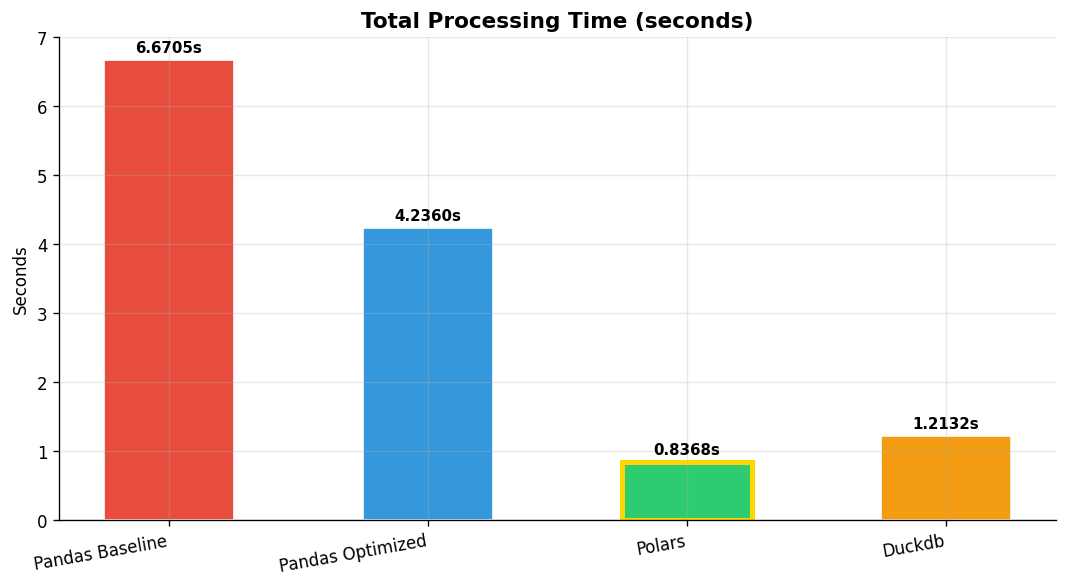

In [3]:
fig, ax = plt.subplots(figsize=(9, 5))

vals     = df_avg['time_sec'].tolist()
best_idx = int(np.argmin(vals))
edges    = ['gold' if i == best_idx else 'white' for i in range(len(vals))]
widths   = [3      if i == best_idx else 1       for i in range(len(vals))]

bars = ax.bar(labels, vals, color=colors,
              edgecolor=edges, linewidth=widths, width=0.5)

for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + max(vals) * 0.01,
            f'{val:.4f}s', ha='center', va='bottom',
            fontsize=9, fontweight='bold')

ax.set_title('Total Processing Time (seconds)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Seconds')
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=10, ha='right')

plt.tight_layout()
plt.savefig('chart2_time.png', dpi=150, bbox_inches='tight')
plt.show()

## Chart 2 — CPU Usage

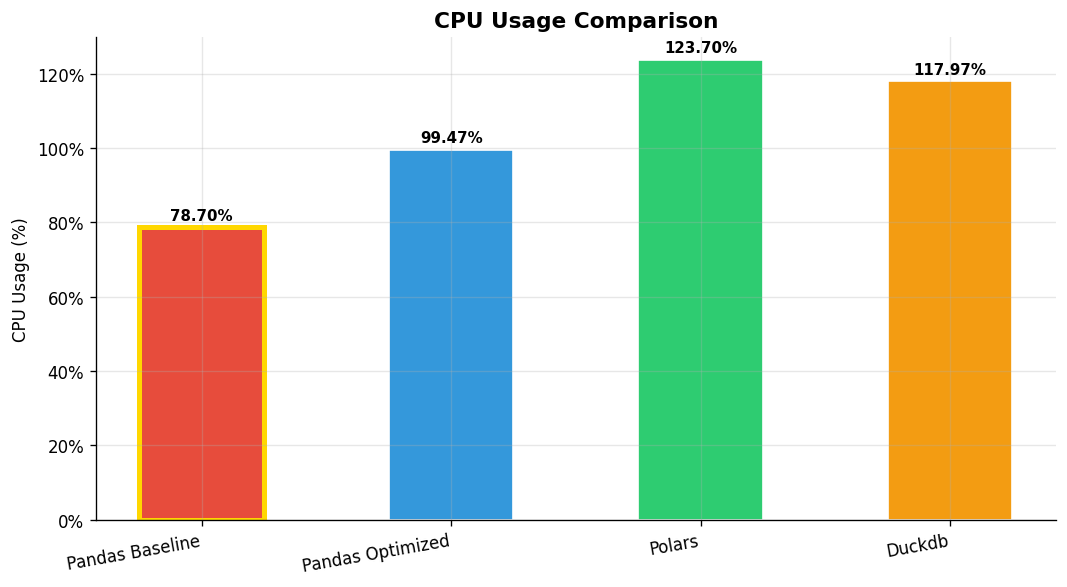

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))

vals = df_avg['cpu_percent'].tolist()

best_idx = int(np.argmin(vals))
edges = ['gold' if i == best_idx else 'white' for i in range(len(vals))]
widths = [3 if i == best_idx else 1 for i in range(len(vals))]

bars = ax.bar(labels, vals, color=colors,
              edgecolor=edges, linewidth=widths, width=0.5)

for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + max(vals) * 0.01,
            f'{val:.2f}%',
            ha='center', va='bottom',
            fontsize=9, fontweight='bold')

ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))

ax.set_title('CPU Usage Comparison',
             fontsize=13, fontweight='bold')
ax.set_ylabel('CPU Usage (%)')
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=10, ha='right')

plt.tight_layout()
plt.savefig('chart_cpu_usage.png', dpi=150, bbox_inches='tight')
plt.show()

## Chart 3 — Memory Usage

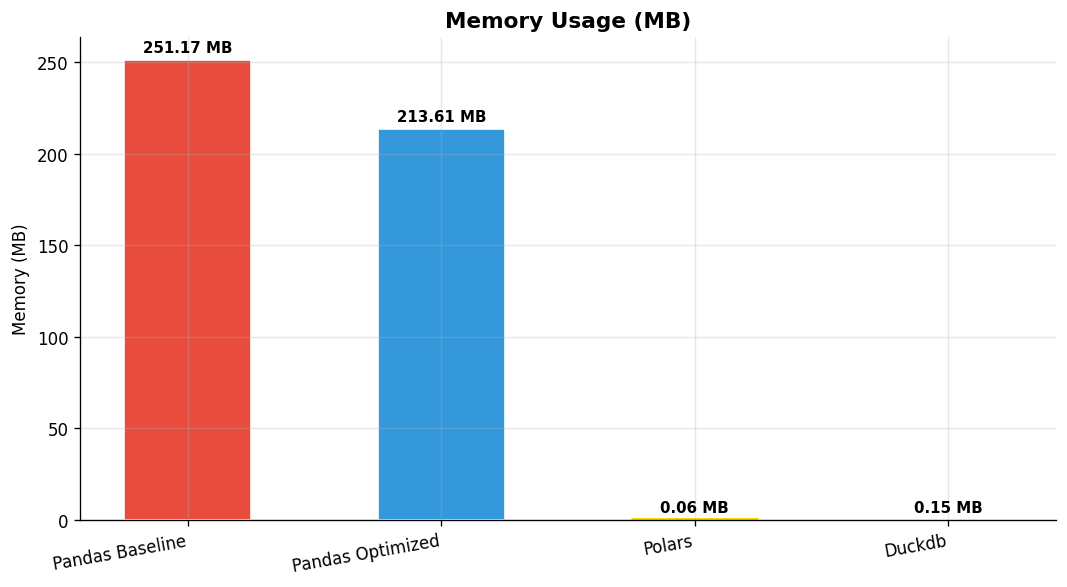

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))

vals     = df_avg['memory_mb'].tolist()
best_idx = int(np.argmin(vals))
edges    = ['gold' if i == best_idx else 'white' for i in range(len(vals))]
widths   = [3      if i == best_idx else 1       for i in range(len(vals))]

bars = ax.bar(labels, vals, color=colors,
              edgecolor=edges, linewidth=widths, width=0.5)

for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + max(vals) * 0.01,
            f'{val:.2f} MB', ha='center', va='bottom',
            fontsize=9, fontweight='bold')

ax.set_title('Memory Usage (MB)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Memory (MB)')
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=10, ha='right')

plt.tight_layout()
plt.savefig('chart3_memory.png', dpi=150, bbox_inches='tight')
plt.show()

## Chart 4 — Throughput (Records/Second)

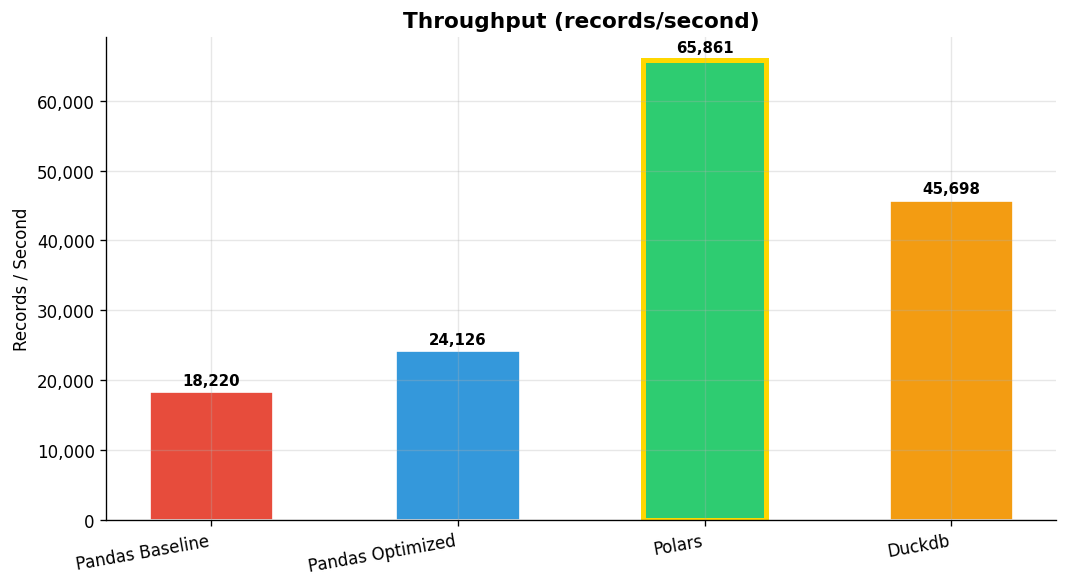

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))

vals     = df_avg['throughput_records_per_sec'].tolist()
best_idx = int(np.argmax(vals))
edges    = ['gold' if i == best_idx else 'white' for i in range(len(vals))]
widths   = [3      if i == best_idx else 1       for i in range(len(vals))]

bars = ax.bar(labels, vals, color=colors,
              edgecolor=edges, linewidth=widths, width=0.5)

for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + max(vals) * 0.01,
            f'{val:,.0f}', ha='center', va='bottom',
            fontsize=9, fontweight='bold')

ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.set_title('Throughput (records/second)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Records / Second')
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=10, ha='right')

plt.tight_layout()
plt.savefig('chart4_throughput.png', dpi=150, bbox_inches='tight')
plt.show()

## Chart 5 — Speedup vs Baseline

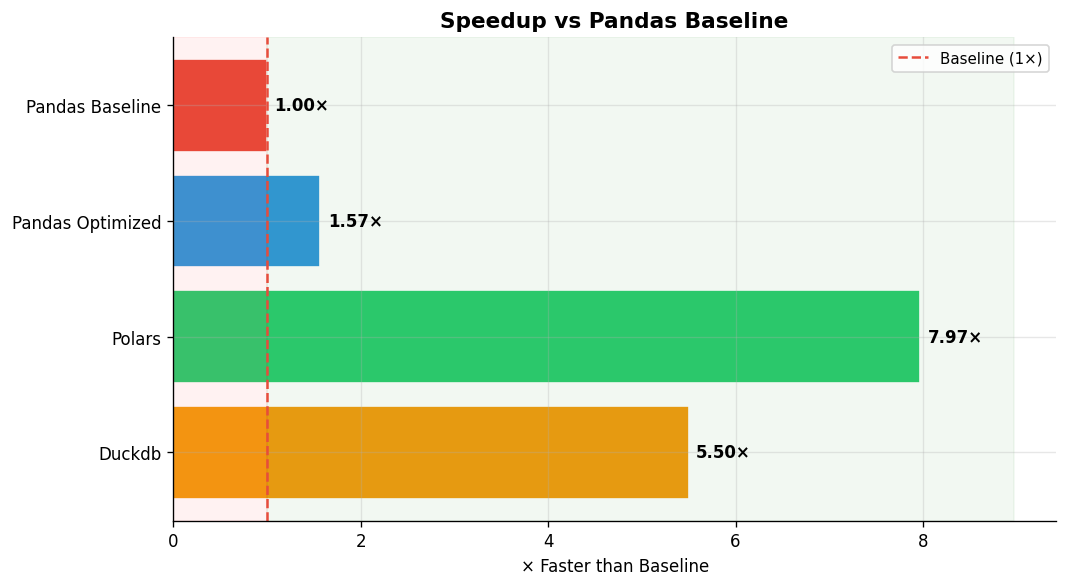

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))

speedups = df_avg['speedup_vs_baseline'].tolist()

bars = ax.barh(labels[::-1], speedups[::-1],
               color=colors[::-1], edgecolor='white', linewidth=1)

ax.axvline(x=1.0, color='#e74c3c', linestyle='--',
           linewidth=1.5, label='Baseline (1×)')
ax.axvspan(0, 1, alpha=0.05, color='red')
ax.axvspan(1, max(speedups) + 1, alpha=0.05, color='green')

for bar, val in zip(bars, speedups[::-1]):
    ax.text(val + max(speedups) * 0.01,
            bar.get_y() + bar.get_height()/2,
            f'{val:.2f}×', va='center',
            fontsize=10, fontweight='bold')

ax.set_title('Speedup vs Pandas Baseline',
             fontsize=13, fontweight='bold')
ax.set_xlabel('× Faster than Baseline')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('chart5_speedup.png', dpi=150, bbox_inches='tight')
plt.show()

## Chart 6 — Comparison: Time, CPU, Memory, Throughput

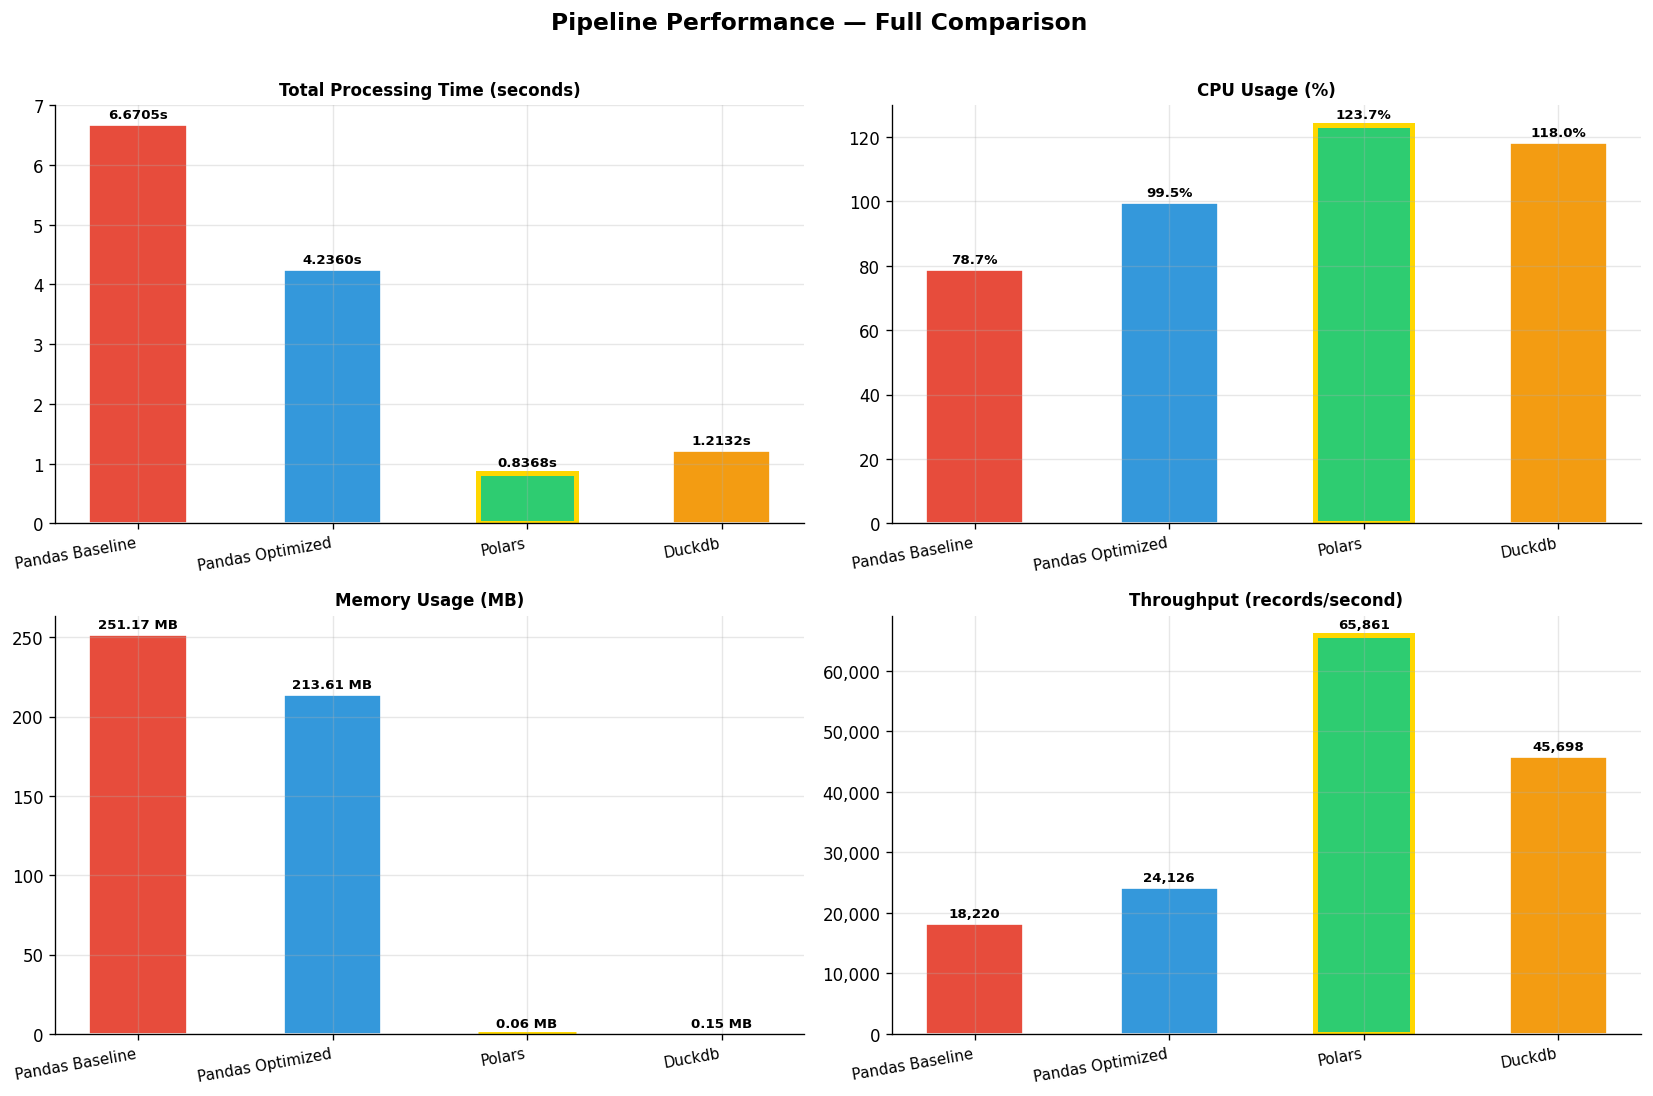

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Pipeline Performance — Full Comparison',
             fontsize=14, fontweight='bold', y=1.01)

configs = [
    (
        'time_sec',
        'Total Processing Time (seconds)',
        'lower',
        '{:.4f}s',
        None,
        axes[0, 0]
    ),
    (
        'cpu_percent',
        'CPU Usage (%)',
        'higher',
        '{:.1f}%',
        None,
        axes[0, 1]
    ),
    (
        'memory_mb',
        'Memory Usage (MB)',
        'lower',
        '{:.2f} MB',
        None,
        axes[1, 0]
    ),
    (
        'throughput_records_per_sec',
        'Throughput (records/second)',
        'higher',
        '{:,.0f}',
        mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'),
        axes[1, 1]
    ),
]

for col, title, direction, fmt_str, y_formatter, ax in configs:
    vals     = df_avg[col].tolist()
    best_idx = int(np.argmin(vals)) if direction == 'lower' else int(np.argmax(vals))
    edges    = ['gold' if i == best_idx else 'white' for i in range(len(vals))]
    widths   = [3      if i == best_idx else 1       for i in range(len(vals))]

    bars = ax.bar(labels, vals, color=colors,
                  edgecolor=edges, linewidth=widths, width=0.5)

    for bar, val in zip(bars, vals):
        label_text = fmt_str.format(val)
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(vals) * 0.01,
                label_text, ha='center', va='bottom',
                fontsize=8, fontweight='bold')

    if y_formatter:
        ax.yaxis.set_major_formatter(y_formatter)

    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=10, ha='right', fontsize=9)

plt.tight_layout()
plt.savefig('chart6_combined.png', dpi=150, bbox_inches='tight')
plt.show()